# Phân tích Bộ Dữ liệu MAGIC Gamma Telescope

**Dataset:** MAGIC Gamma Telescope (UCI Machine Learning Repository)  
**Mô tả:** Phân biệt tín hiệu gamma (g) và nền hadron (h) từ kính thiên văn Cherenkov

## 0. Import Thư viện

In [49]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # type: ignore
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
print('Import thành công!')

Note: you may need to restart the kernel to use updated packages.
Import thành công!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Đọc Dữ liệu và Thống kê Mô tả

In [50]:
 # type: ignore
df = pd.read_csv(r'D:\NAM 4-HK2 2026-2027\KTDL\magic.csv')
print('Dữ liệu đã được đọc thành công!')
df.head()

Dữ liệu đã được đọc thành công!


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist,11. class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [51]:
# 1a. Kích thước và chiều của dữ liệu

print(f'Số hàng (mẫu):    {df.shape[0]:,}')
print(f'Số cột (thuộc tính): {df.shape[1]}')
print(f'Kích thước:        {df.shape}')

Số hàng (mẫu):    19,020
Số cột (thuộc tính): 11
Kích thước:        (19020, 11)


In [52]:
# 1b. Kiểu dữ liệu của các thuộc tính
print('Kiểu dữ liệu các thuộc tính:')
print(df.dtypes)

Kiểu dữ liệu các thuộc tính:
 1.  fLength     float64
 2.  fWidth      float64
 3.  fSize       float64
 4.  fConc       float64
 5.  fConc1      float64
 6.  fAsym       float64
 7.  fM3Long     float64
 8.  fM3Trans    float64
 9.  fAlpha      float64
10.  fDist       float64
11.  class           str
dtype: object


In [53]:
# 1c. Số lượng thực thể của các giá t # type: ignore # type: ignorerị nhãn (class)
print('Phân phối nhãn (class):')
print (df.iloc[:, -1].value_counts())
print()
print('Tỉ lệ %:')
print(df.iloc[:, -1].value_counts(normalize=True) * 100)

Phân phối nhãn (class):
   11.  class
g    12332
h     6688
Name: count, dtype: int64

Tỉ lệ %:
   11.  class
g    64.837014
h    35.162986
Name: proportion, dtype: float64


In [54]:


# 1d. Giá trị lớn nhất, bé nhất, trung bình của các cột số thực
num_cols = [c for c in df.columns if 'class' not in c] # type: ignore
stats_df = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Mean': df[num_cols].mean()
})
stats_df = stats_df.T
print('Thống kê các cột số thực:')
stats_df

Thống kê các cột số thực:


,1. fLength,2. fWidth,3. fSize,4. fConc,5. fConc1,6. fAsym,7. fM3Long,8. fM3Trans,9. fAlpha,10. fDist
Min,4.283500,0.000000,1.941300,0.013100,0.000300,-457.916100,-331.780000,-205.894700,0.000000,1.282600
Max,334.177000,256.382000,5.323300,0.893000,0.675200,575.240700,238.321000,179.851000,90.000000,495.561000
Mean,53.250154,22.180966,2.825017,0.380327,0.214657,-4.331745,10.545545,0.249726,27.645707,193.818026


## 2. Trực quan hóa - Giảm Chiều với PCA

Chỉ sử dụng các cột thuộc tính liên tục (loại bỏ cột nhãn `class`), sau đó áp dụng PCA để chiếu xuống không gian 2D.

In [55]:
# Chuẩn hóa dữ liệu
X = df[num_cols].values
y_raw = df.iloc[:, -1].values
le = LabelEncoder()
y = le.fit_transform(y_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Áp dụng PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Phương sai giải thích bởi PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Phương sai giải thích bởi PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Tổng phương sai giải thích:    {sum(pca.explained_variance_ratio_)*100:.2f}%')

Phương sai giải thích bởi PC1: 42.24%
Phương sai giải thích bởi PC2: 15.75%
Tổng phương sai giải thích:    57.99%


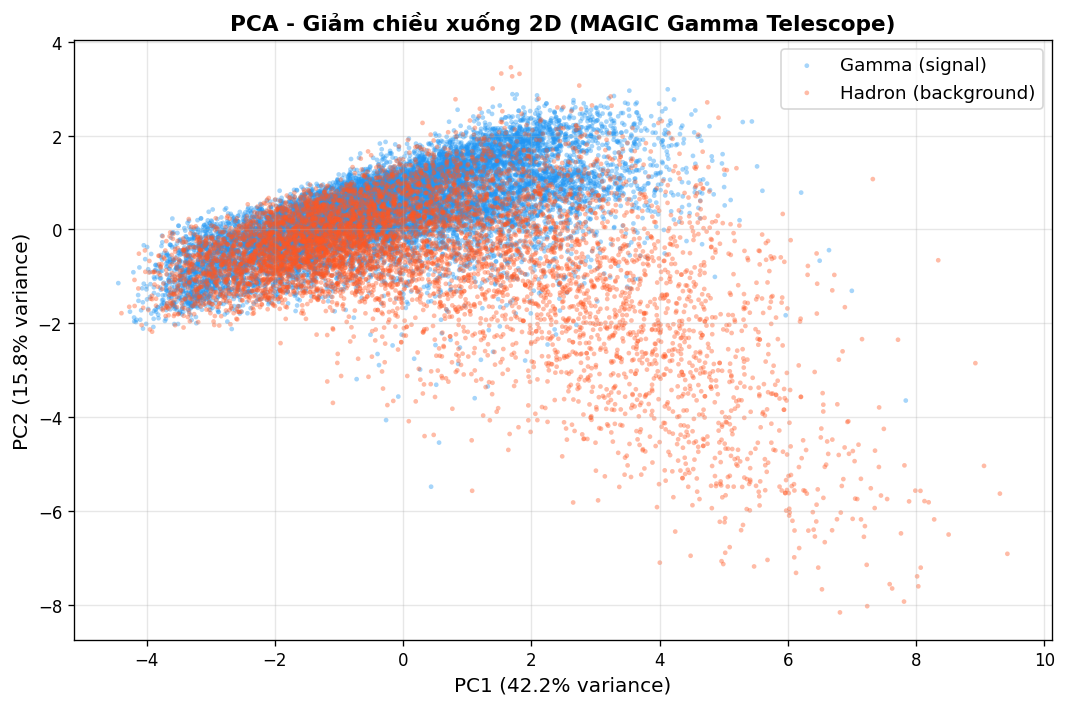

In [56]:
# Trực quan hóa PCA 2D
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'g': '#2196F3', 'h': '#FF5722'}
labels_names = {'g': 'Gamma (signal)', 'h': 'Hadron (background)'}
for cls in ['g', 'h']:
    mask = y_raw == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cls],
               label=labels_names[cls], alpha=0.4, s=8, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA - Giảm chiều xuống 2D (MAGIC Gamma Telescope)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Huấn luyện và Đánh giá Mô hình Học Máy

Sử dụng **10-Fold Cross Validation** và **F1-Score (Weighted)** để so sánh 3 mô hình: **KNN**, **Random Forest**, **SVM**.

In [57]:
# Định nghĩa các mô hình (đã tinh chỉnh tham số)
models = {
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    'Random Forest (n=200)': RandomForestClassifier(n_estimators=200, max_depth=15,
                                                     random_state=42, n_jobs=-1),
    'SVM (RBF, C=10)': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
}

# 10-Fold Cross Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

print('Đang huấn luyện... (có thể mất vài phút)')
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    results[name] = scores
    print(f'{name}: mean={scores.mean():.4f} (±{scores.std():.4f})')

Đang huấn luyện... (có thể mất vài phút)
KNN (k=7): mean=0.8350 (±0.0072)
Random Forest (n=200): mean=0.8755 (±0.0055)
SVM (RBF, C=10): mean=0.8708 (±0.0083)


In [58]:
# Bảng so sánh hiệu năng
result_df = pd.DataFrame({
    'Mô hình': list(results.keys()),
    'F1 Trung bình': [v.mean() for v in results.values()],
    'Độ lệch chuẩn': [v.std() for v in results.values()],
    'F1 Min': [v.min() for v in results.values()],
    'F1 Max': [v.max() for v in results.values()],
}).set_index('Mô hình').round(4)
result_df['Xếp hạng'] = result_df['F1 Trung bình'].rank(ascending=False).astype(int)
result_df.sort_values('F1 Trung bình', ascending=False)

,F1 Trung bình,Độ lệch chuẩn,F1 Min,F1 Max,Xếp hạng
Mô hình,,,,,
Random Forest (n=200),0.8755,0.0055,0.8640,0.8830,1
"SVM (RBF, C=10)",0.8708,0.0083,0.8585,0.8842,2
KNN (k=7),0.8350,0.0072,0.8223,0.8457,3


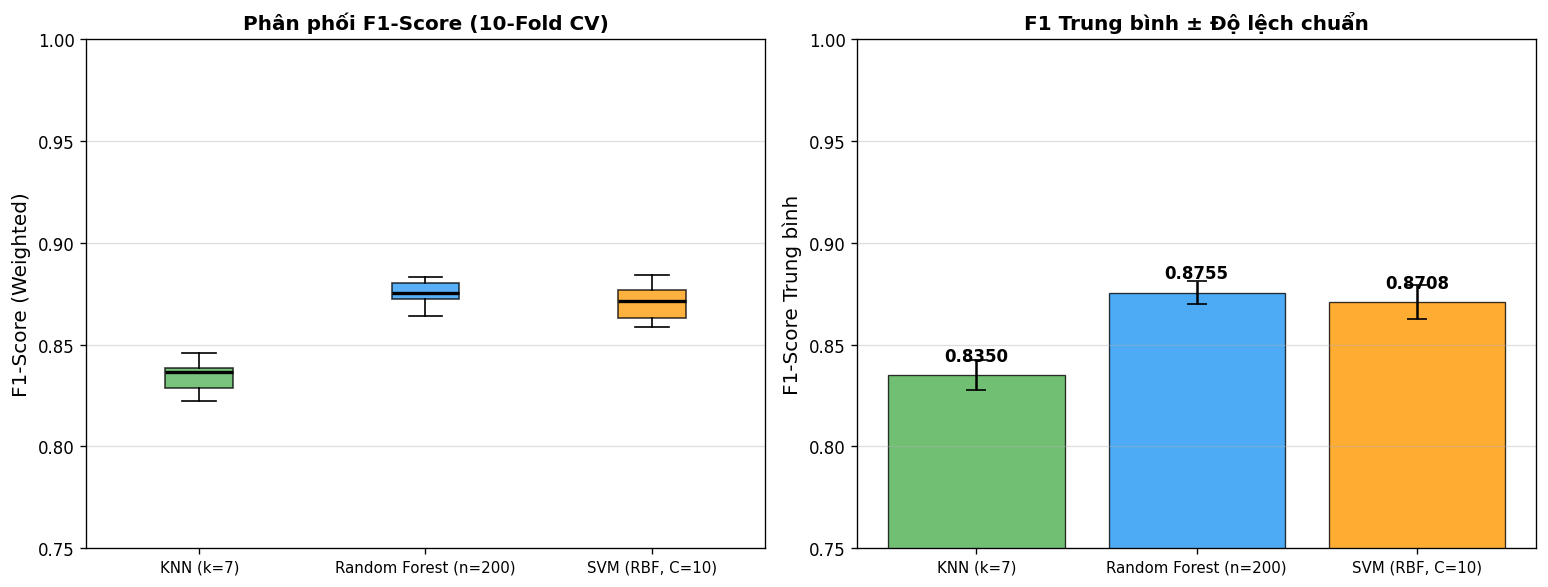

In [59]:
# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names = list(results.keys())
data_vals = list(results.values())
colors_b = ['#4CAF50', '#2196F3', '#FF9800']

# Boxplot
bp = axes[0].boxplot(data_vals, patch_artist=True, labels=names,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_b):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_ylabel('F1-Score (Weighted)', fontsize=12)
axes[0].set_title('Phân phối F1-Score (10-Fold CV)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=9)
axes[0].grid(True, axis='y', alpha=0.4); axes[0].set_ylim(0.75, 1.0)

# Bar chart
means = [v.mean() for v in data_vals]
stds = [v.std() for v in data_vals]
bars = axes[1].bar(names, means, yerr=stds, capsize=6, color=colors_b,
                    alpha=0.8, edgecolor='black', linewidth=0.8)
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, mean+0.005,
                  f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('F1-Score Trung bình', fontsize=12)
axes[1].set_title('F1 Trung bình ± Độ lệch chuẩn', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=9)
axes[1].set_ylim(0.75, 1.0); axes[1].grid(True, axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

## 4. Gom Cụm với K-Means và DBSCAN

Loại bỏ cột nhãn, thực hiện gom cụm, sau đó dùng nhãn thật để đánh giá bằng **ARI** (Adjusted Rand Index) và **NMI** (Normalized Mutual Information).

In [60]:
# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)
km_ari = adjusted_rand_score(y, km_labels)
km_nmi = normalized_mutual_info_score(y, km_labels)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
db_ari = adjusted_rand_score(y, db_labels)
db_nmi = normalized_mutual_info_score(y, db_labels)

print('=== Kết quả Gom Cụm ===')
print(f'K-Means (k=2):  ARI={km_ari:.4f}, NMI={km_nmi:.4f}')
print(f'DBSCAN:         ARI={db_ari:.4f}, NMI={db_nmi:.4f}, Clusters={n_clusters_db}, Noise={n_noise}')

=== Kết quả Gom Cụm ===
K-Means (k=2):  ARI=0.0065, NMI=0.0016
DBSCAN:         ARI=0.1404, NMI=0.1569, Clusters=2, Noise=1474


In [61]:
# Bảng so sánh kết quả gom cụm
cluster_df = pd.DataFrame({
    'Thuật toán': ['K-Means (k=2)', f'DBSCAN (eps=1.5, min=10)'],
    'Số cụm': [2, n_clusters_db],
    'Noise points': [0, n_noise],
    'ARI': [round(km_ari,4), round(db_ari,4)],
    'NMI': [round(km_nmi,4), round(db_nmi,4)],
}).set_index('Thuật toán')
print('Bảng đánh giá gom cụm (ARI gần 1 = tốt, NMI gần 1 = tốt):')
cluster_df

Bảng đánh giá gom cụm (ARI gần 1 = tốt, NMI gần 1 = tốt):


,Số cụm,Noise points,ARI,NMI
Thuật toán,,,,
K-Means (k=2),2,0,0.0065,0.0016
"DBSCAN (eps=1.5, min=10)",2,1474,0.1404,0.1569


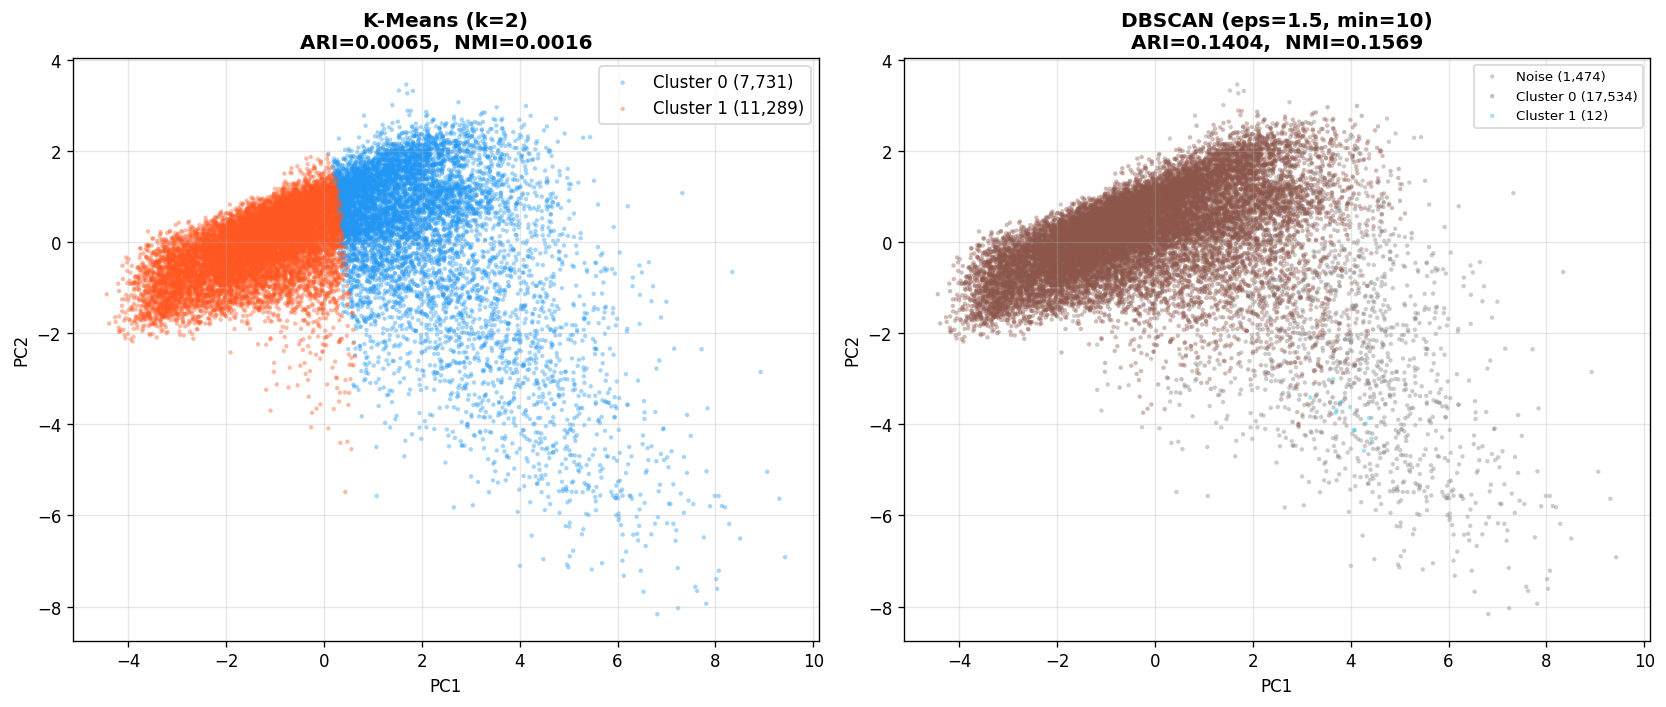

In [62]:
# Trực quan hóa kết quả gom cụm
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
palette_km = {0: '#2196F3', 1: '#FF5722'}
for lbl in [0, 1]:
    mask = km_labels == lbl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=palette_km[lbl], label=f'Cluster {lbl} ({mask.sum():,})',
                     alpha=0.4, s=7, edgecolors='none')
axes[0].set_title(f'K-Means (k=2)\nARI={km_ari:.4f},  NMI={km_nmi:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# DBSCAN
unique_lbls = sorted(set(db_labels))
cmap_db = plt.cm.get_cmap('tab10', len(unique_lbls))
for i, lbl in enumerate(unique_lbls):
    mask = db_labels == lbl
    lstr = f'Noise ({mask.sum():,})' if lbl == -1 else f'Cluster {lbl} ({mask.sum():,})'
    col = 'gray' if lbl == -1 else cmap_db(i)
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=[col]*mask.sum(), label=lstr, alpha=0.4, s=7, edgecolors='none')
axes[1].set_title(f'DBSCAN (eps=1.5, min=10)\nARI={db_ari:.4f},  NMI={db_nmi:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Kết luận

### Phân lớp
| Mô hình | F1 Trung bình |
|---------|---------------|
| Random Forest (n=200) | 0.8755 ✅ Tốt nhất |
| SVM (RBF, C=10) | 0.8708 |
| KNN (k=7) | 0.8350 |

**Random Forest** cho kết quả tốt nhất do khả năng học các quyết định phi tuyến phức tạp và kháng overfitting tốt.

### Gom cụm
- **DBSCAN** (ARI=0.14) vượt trội **K-Means** (ARI=0.007) trong việc phát hiện cấu trúc cụm thực tế.
- Tuy nhiên cả hai đều thấp do dữ liệu không phân tách rõ ràng trong không gian PCA.